In [1]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 136.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15


In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import Image
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="5eAF35LwtHyAOMlnZHGC")
project = rf.workspace("new-workspace-rhiq8").project("bottle-yolo-asg0r")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to bottle-YOLO-3 in yolov8:: 100%|██████████| 168/168 [00:00<00:00, 5665.06it/s]


In [5]:
import os

print(os.listdir(dataset.location))

['README.roboflow.txt', 'data.yaml', 'train', 'test', 'README.dataset.txt', 'valid']


In [6]:
yaml_path = f"{dataset.location}/data.yaml"

with open(yaml_path, 'r') as f:
    print(f.read())

names:
- bag
- bottle
- eye drop
nc: 3
roboflow:
  license: CC BY 4.0
  project: bottle-yolo-asg0r
  url: https://universe.roboflow.com/new-workspace-rhiq8/bottle-yolo-asg0r/dataset/3
  version: 3
  workspace: new-workspace-rhiq8
test: ../test/images
train: ../train/images
val: ../valid/images



In [7]:
model = YOLO("yolov8n.pt")

In [8]:
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    name="custom_yolo_training"
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bottle-YOLO-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolo_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [10]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2019.0±696.6 MB/s, size: 55.4 KB)
val: Scanning /content/bottle-YOLO-3/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 10, len(boxes) = 11. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.1it/s 0.3s
                   all         10         11      0.856      0.807      0.928      0.804
                   bag          5          5          1       0.62      0.995      0.753
                bottle          5          5      0.651        0.8      0.795      0.765
              eye drop          1    

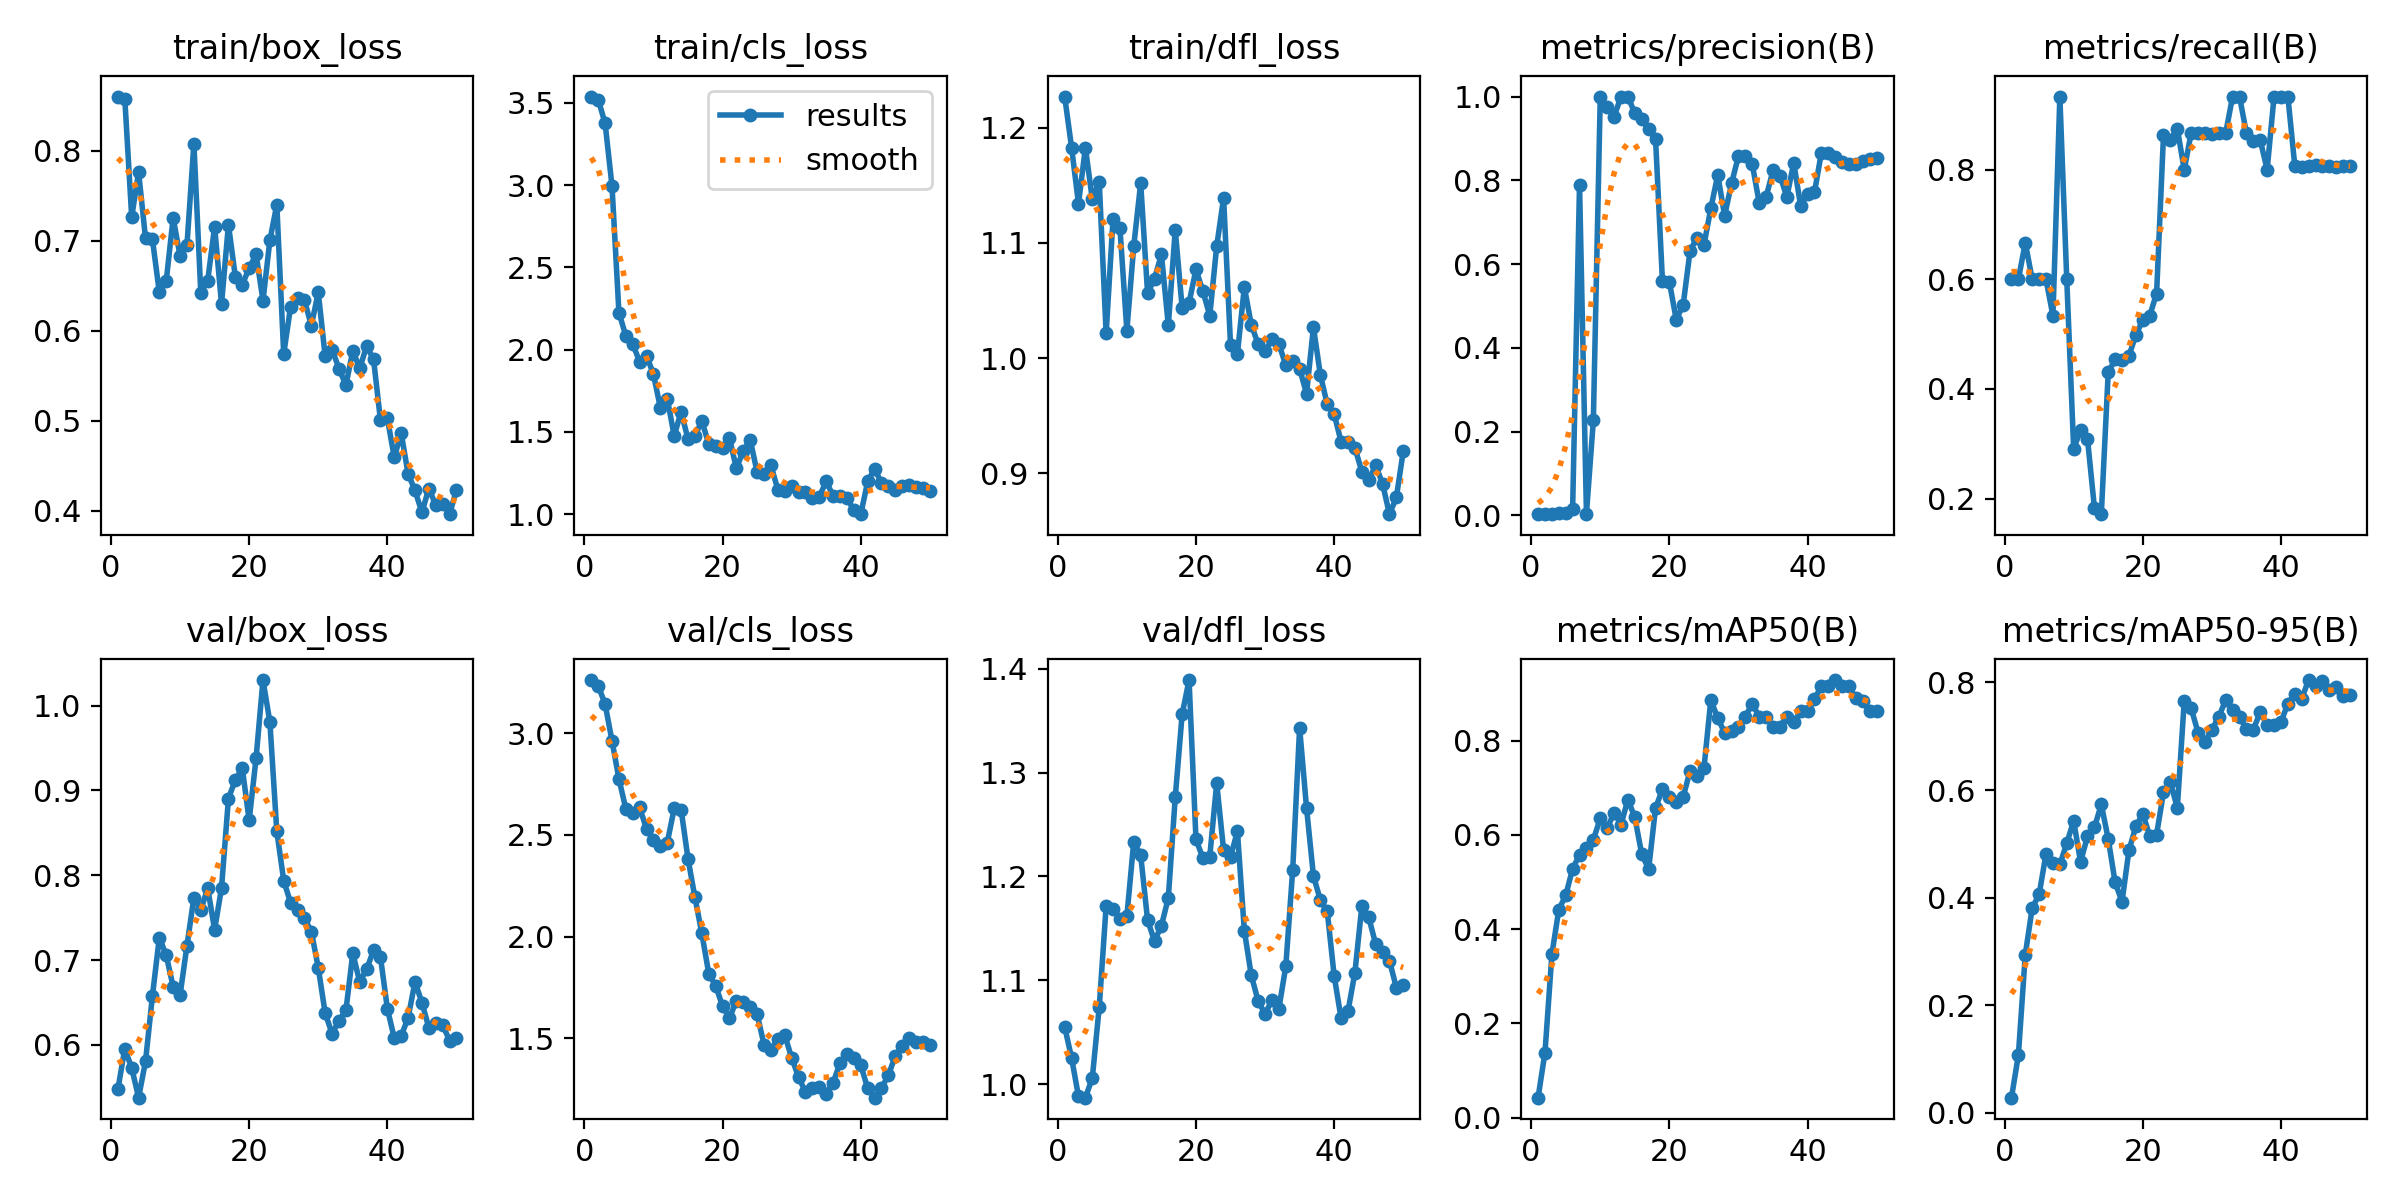

In [ ]:
Image(filename='runs/detect/custom_yolo_training/results.png')

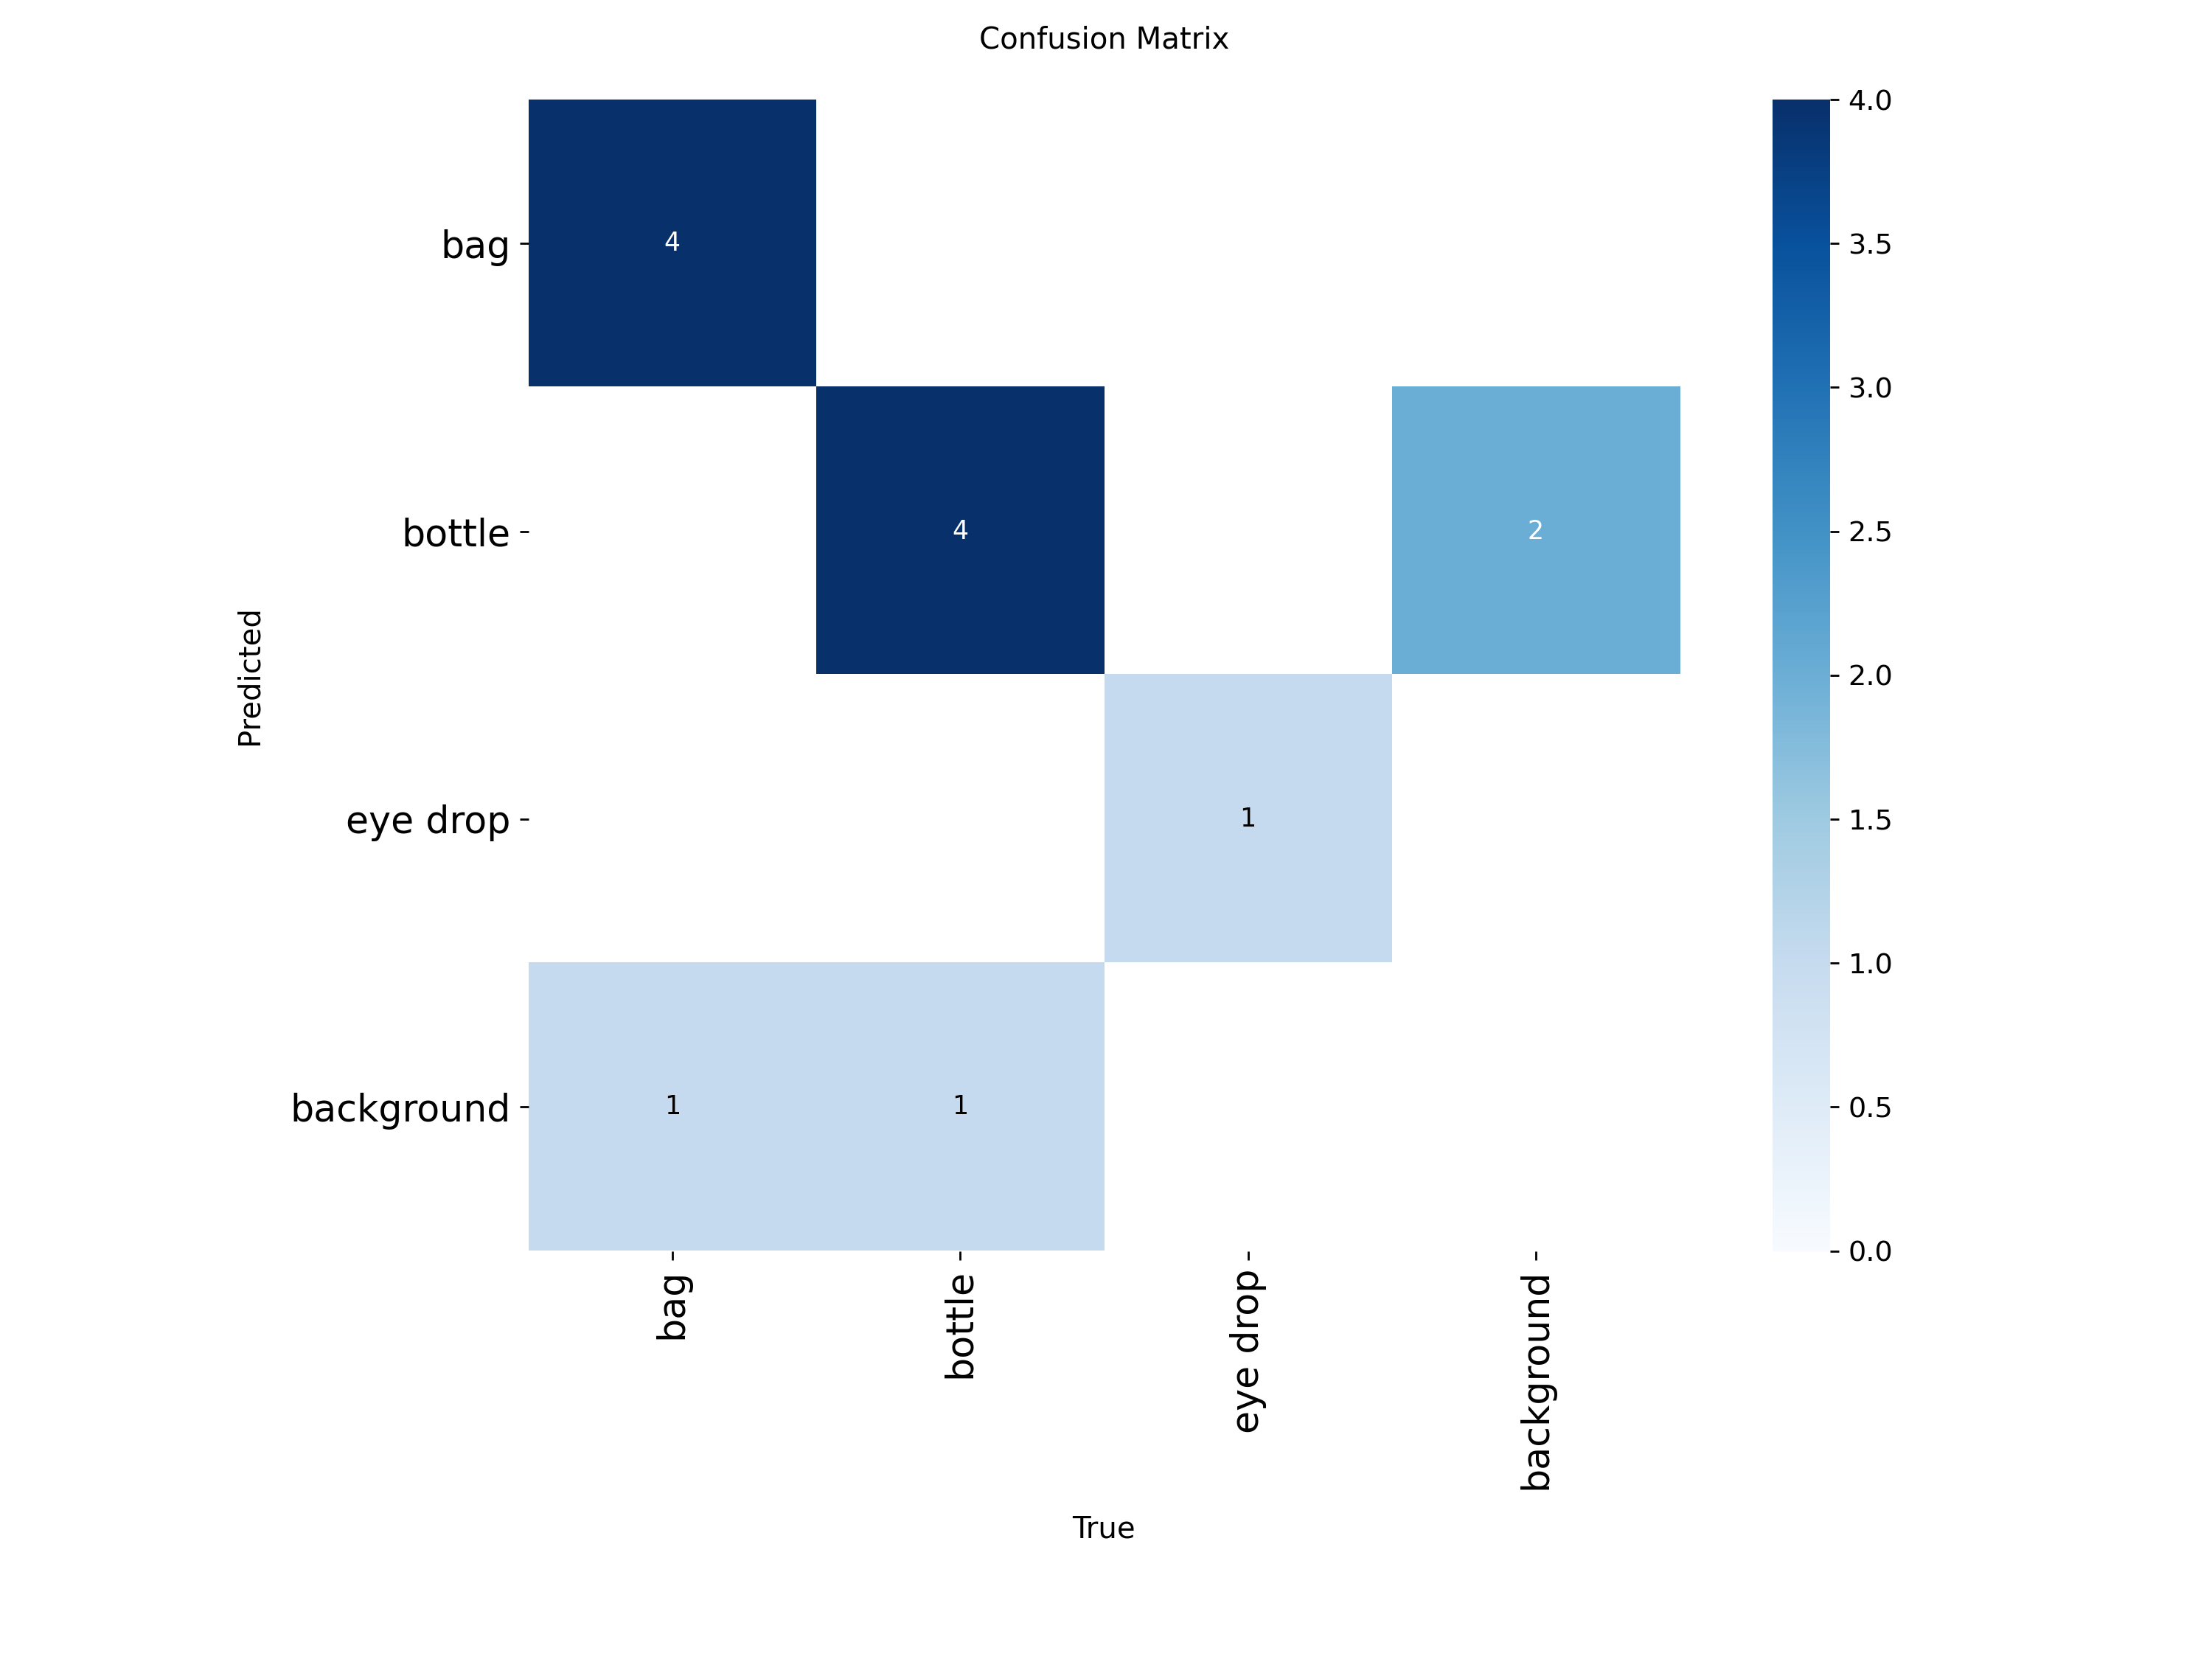

In [11]:
Image(filename='runs/detect/custom_yolo_training/confusion_matrix.png')

In [12]:
from google.colab import files

uploaded = files.upload()

Saving prueba.png to prueba.png


In [14]:
best_model = YOLO('runs/detect/custom_yolo_training/weights/best.pt')

results = best_model(
    source='prueba.png',
    save=True,
    conf=0.25
)


image 1/1 /content/prueba.png: 640x512 1 bag, 1 bottle, 10.6ms
Speed: 2.9ms preprocess, 10.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 512)
Results saved to /content/runs/detect/predict-2


In [19]:
import glob

predicted_images = glob.glob('runs/detect/predict/*jpg')

predicted_images

['runs/detect/predict/prueba.jpg']

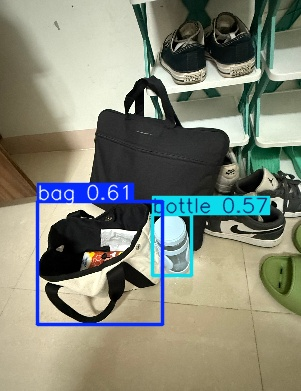

In [20]:
Image(filename=predicted_images[0])

In [ ]:
best_model.export(format='onnx')

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from 'runs/detect/custom_yolo_training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.3s, saved as 'runs/detect/custom_yolo_training/weights/best.onnx' (11.7 MB)

Export complete (1.6s)
Results saved to /content/runs/detect/custom_yolo_training/weights/best.onnx
Predict:         yolo predict task=detect model=runs/detect/custom_yolo_training/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/custom_yolo_training/weights/best.onnx imgsz=640 data=/content/bottle-YOLO-3/data.yaml  
Visualize:       https://netron.app


'runs/detect/custom_yolo_training/weights/best.onnx'

In [ ]:
from google.colab import files

files.download('runs/detect/custom_yolo_training/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('runs/detect/custom_yolo_training/results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>